In [1]:
%pylab inline

import sys
import numpy as np
from numpy.random import shuffle
from matplotlib import pyplot as plt
%matplotlib inline

from sklearn.ensemble import RandomForestClassifier
import itertools
import copy
from astropy.coordinates import SkyCoord
import pandas as pd

import change_path
import GCRCatalogs
from astropy.table import Table

Populating the interactive namespace from numpy and matplotlib


In [2]:
import point_metrics

In [2]:
n_bins = 101
z_min = 0
z_max = 3
rz_ind = 1

llinewidth = 5
label_fontsize = 12
title_fontsize = 20
legend_fontsize = 14
tick_fontsize = 13
ppointsize = 8
ccapsize = 12

In [3]:
#Define the grid based on bin arrangements

grid_Y = np.linspace(z_min, z_max, num=n_bins)
delta_z = grid_Y[1:] - grid_Y[:-1]
midpoints = grid_Y[:-1] + delta_z/2

In [4]:
# Read our result

par_loc = '/global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/OLIVIA_WORK/final-result.parquet'
result_data_table = pd.read_parquet(par_loc)

In [5]:
result_data_table

,galid,mag_i,rz_real,photoz_mode,photoz_pdf
0,9.687500e+09,15.750296,0.021528,0.015,"[19.53333333333333, 3.0666666666666664, 9.9333..."
1,9.687500e+09,19.032953,0.020944,0.165,"[0.4, 5.133333333333334, 4.9333333333333345, 4..."
2,9.687500e+09,16.886229,0.020472,0.045,"[0.0, 9.333333333333332, 5.666666666666668, 9...."
3,9.687500e+09,17.331247,0.017873,0.135,"[0.0, 1.4666666666666666, 0.4, 6.9333333333333..."
4,9.687500e+09,13.780033,0.021042,0.015,"[22.53333333333333, 9.733333333333334, 1.06666..."
...,...,...,...,...,...
8322244,8.957676e+09,24.936487,2.950109,0.165,"[0.0, 0.0, 0.9333333333333335, 1.5333333333333..."
8322245,8.957677e+09,24.942907,2.990951,0.165,"[0.0, 0.0, 0.7333333333333333, 1.7333333333333..."
8322246,8.957677e+09,23.770533,2.979557,0.075,"[0.0, 0.5333333333333333, 4.800000000000002, 4..."
8322247,8.957677e+09,24.659365,2.979557,0.165,"[0.0, 0.0, 2.5333333333333337, 3.5333333333333..."


In [6]:
# Read our result of the whole ensemble

sys_ave =  Table.read('/global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/OLIVIA_WORK/result3_sys.fits')

In [8]:
from scipy import integrate
ave_list = []
for i in range(50):
    ave_list += [integrate.simps(sys_ave['col0'][i],midpoints)]
mean_ens = np.mean(ave_list)
ast_ens = np.std(ave_list)

In [9]:
mean_ens

0.9999604641100299

In [10]:
ast_ens

0.00012463309048471092

In [7]:
# Read true redshift info for analysis purpose

inquired_data = GCRCatalogs.load_catalog('cosmoDC2_v1.1.4_small_photoz_magerr_10y')

mag_filters = [
    (np.isfinite, 'mag_i_obs'),
    'mag_i_obs < 25.0',] #the cut that is consistent with what Sam uses

data_process = inquired_data.get_quantities(['galaxy_id','redshift_true','ra', 'dec', 'mag_u_obs','magerr_u_obs',
                                        'mag_g_obs','magerr_g_obs','mag_r_obs','magerr_r_obs','mag_i_obs',
                                        'magerr_i_obs','mag_z_obs','magerr_z_obs','mag_y_obs','magerr_y_obs'],
                                       filters=mag_filters)

data_process_1 = pd.DataFrame(data_process)
reordered_column = ['galaxy_id','redshift_true','ra', 'dec', 'mag_u_obs','magerr_u_obs','mag_g_obs','magerr_g_obs',
                       'mag_r_obs','magerr_r_obs','mag_i_obs','magerr_i_obs','mag_z_obs','magerr_z_obs',
                   'mag_y_obs','magerr_y_obs']
data_process_2 = data_process_1[reordered_column]
format_data = data_process_2.values

# Limit to the range of reshift value we are inspecting
test = format_data[(format_data[:,rz_ind] >= z_min) & (format_data[:,rz_ind] < z_max)]
testing_size = len(test)

%xdel inquired_data
%xdel data_process
%xdel data_process_1
%xdel data_process_2

/global/u1/z/zhiyaol/gcr-catalogs/GCRCatalogs/cosmodc2.py:247: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  catalog_version.append(fh['/metaData/version' + version_label].value)
/global/u1/z/zhiyaol/gcr-catalogs/GCRCatalogs/cosmodc2.py:308: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  sky_area_this = fh['metaData/skyArea'].value # pylint: disable=E1101
/global/u1/z/zhiyaol/gcr-catalogs/GCRCatalogs/cosmodc2.py:362: H5pyDeprecationWarning: dataset.value has been deprecated. Use dataset[()] instead.
  yield lambda native_quantity: fh['{}/{}'.format(group, native_quantity)].value


In [19]:
test_true = np.histogram(test[:,rz_ind],n_bins-1)
true_z = test_true[1]
true_p = test_true[0]/(len(test)*(z_max/(n_bins-1)))
integrate.simps(true_p,midpoints)

0.9999365756379874

In [20]:
0.9999604641100299-0.9999365756379874

2.3888472042488118e-05

In [21]:
0.00012463309048471092

0.00012463309048471092

In [12]:
# Loading the training set for analysis purpose

train_dat_dir = '/global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/TESTRUN/sample_cosmodc2_w10year_errors.dat'
train_data = np.loadtxt(train_dat_dir, skiprows=1)
format_train = np.delete(train_data,[16,17],1)


# Limit to the range of reshift value we are inspecting
train = format_train[(format_train[:,rz_ind] >= z_min) & (format_train[:,rz_ind] < z_max) & (format_train[:,10] <= 25.0)]
 #appy to rows individually
training_size = len(train)

#delete no longer needed variables to free up memory
%xdel train_data
%xdel format_train

In [13]:
training_size

83116

In [8]:
# Get photoz_pdf info

ave_prob_vec_tab = np.array(result_data_table['photoz_pdf'])
mode_table = np.array(result_data_table['photoz_mode'])

In [9]:
# Get mean and std for ensemble distribution to do analysis on whole ensemble

syst_ave = np.array(sys_ave['col0'])
mean = np.mean(syst_ave,axis = 0)
std = np.std(syst_ave,axis = 0)

In [16]:
# Plot predicted redshift distribution of testing set vs real distribution of the chosen set


def plot_pred_real(real_set):
    fig, ax = plt.subplots(1)
    real = np.histogram(real_set[:,rz_ind],n_bins-1)
    real_z = real[1]
    real_p = real[0]/(len(real_set)*(z_max/(n_bins-1)))
    real_z_space = (real_z[1:]-real_z[:-1])/2
    real_z_mid = real_z[:-1]+real_z_space
    ax.plot(midpoints, mean, lw=2, label='Estimated', color='blue')
    ax.fill_between(midpoints, mean+std, mean-std, facecolor='blue', alpha=0.35, label = '1st ' + r'$\sigma$')
    ax.fill_between(midpoints, mean+2*std, mean-2*std, facecolor='blue', alpha=0.15, label = '2nd ' + r'$\sigma$')
    ax.fill_between(midpoints, mean+3*std, mean-3*std, facecolor='blue', alpha=0.1, label = '3rd ' + r'$\sigma$')
    ax.set_title('Testing Set Ensemble Result')
    ax.plot(real_z_mid, real_p, '--',lw=2, label='True', color='red')
    xticks(np.arange(0, 3.1, step=0.5))
    yticks(np.arange(0, 1.5, step=0.2))
    plt.tick_params(axis='both', which='major', length = 8, width = 2,labelsize=tick_fontsize,grid_linewidth=0.2)
    ax.legend(loc='upper right')
    ax.set_xlabel('Redshift',fontsize=tick_fontsize)
    ax.set_ylabel('Normalized Prob',fontsize=tick_fontsize)
    ax.grid()  
    return None

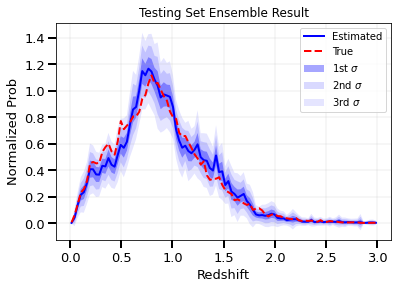

In [17]:
plot_pred_real(test)

Text(0, 0.5, 'Normalized Prob')

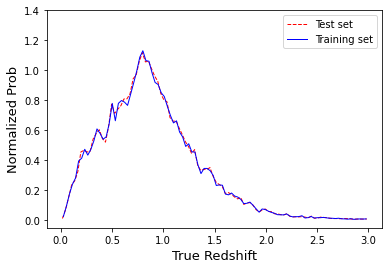

In [18]:
# developing
fig1, ax1 = plt.subplots(1)
testing = np.histogram(test[:,rz_ind],n_bins-1)
test_z = testing[1]
test_p = testing[0]/(len(test)*(z_max/(n_bins-1)))
test_z_space = (test_z[1:]-test_z[:-1])/2
test_z_mid = test_z[:-1]+test_z_space
ax1.plot(test_z_mid, test_p, '--',lw=1, label='Test set', color='red')
training = np.histogram(train[:,rz_ind],n_bins-1)
train_z = training[1]
train_p = training[0]/(len(train)*(z_max/(n_bins-1)))
train_z_space = (train_z[1:]-train_z[:-1])/2
train_z_mid = train_z[:-1]+train_z_space
ax1.plot(train_z_mid, train_p, lw=1, label='Training set', color='blue')
#ax1.set_title('True Redshift Distribution')
ax1.legend(loc='upper right')
xticks(np.arange(0, 3.1, step=0.5))
yticks(np.arange(0, 1.5, step=0.2))
ax1.set_xlabel('True Redshift',fontsize=tick_fontsize)
ax1.set_ylabel('Normalized Prob',fontsize=tick_fontsize)

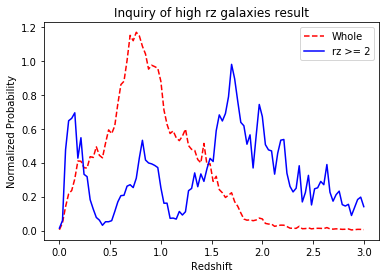

In [13]:
# Analyze high redshift result

fig, m = plt.subplots(1)
m.plot(np.linspace(0,3,100),np.sum(ave_prob_vec_tab)/len(ave_prob_vec_tab), '--', label = 'Whole', color = 'red')
m.plot(np.linspace(0,3,100),
       np.sum(ave_prob_vec_tab[result_data_table['rz_real']>= 2])/len(ave_prob_vec_tab[result_data_table['rz_real']>= 2]),
      label = "rz >= 2", color = 'blue')
m.set_title("Inquiry of high rz galaxies result")
m.set_xlabel("Redshift")
m.set_ylabel("Normalized Probability")
m.legend()

In [12]:
#Get mean redshift for each individual object
#multiply each midpoint with it's probability weight to get a more continuous result distriution
#which takes into consideration the probability density function instead of just the largest prob bin
    
def get_ind_ave(ind_mean_table): 
    ave_table = []
    midstep = midpoints * ind_mean_table*(z_max/(n_bins-1))
    for i in range(len(midstep)): #can try to improve speed by doing array action
        ave_table += [np.sum(midstep[i])]
        if i%1000000 == 0: print(i)
    return ave_table

In [13]:
ave_table = get_ind_ave(ave_prob_vec_tab.tolist())

0
1000000
2000000
3000000
4000000
5000000
6000000
7000000
8000000


In [47]:
eval_point_metric = point_metrics.EvaluatePointStats(ave_table,result_data_table['rz_real'],result_data_table['mag_i'],imagcut=25.0)

In [48]:
eval_point_metric.CalculateSigmaIQR()

(0.06122202173207232, 0.06122202173207232)

In [49]:
eval_point_metric.CalculateBias()

(0.02001711493357055, 0.02001711493357055)

In [50]:
eval_point_metric.CalculateOutlierRate()

using 0.184 for cut for whole sample and 0.184 for magcut sample



(0.06273292231462914, 0.06273292231462914)

In [51]:
eval_point_metric.CalculateSigmaMAD()

(0.0584070059382604, 0.0584070059382604)

In [21]:
# Plot the distribution of mean redshift for individual objects with scattered dots

def plot_MSE(mode_table):
    plt.plot(test[:, rz_ind],mode_table, '.', label='Prediction', ms=0.8)
    plt.plot(np.linspace(0.0, 3.0), np.linspace(0.0, 3.0), label='Optimum')
    MSE = round(np.mean((mode_table - test[:, rz_ind])**2), 3)
    plt.text(0.1, 2.6, r'$MSE = '+str(MSE)+'$', 
         fontsize=20)
    plt.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    plt.xlabel('Real', fontsize=label_fontsize)
    plt.ylabel('Predicted', fontsize=label_fontsize)
    plt.legend(fontsize=legend_fontsize, loc='lower right')
    plt.xlim([0.0, z_max])
    plt.ylim([0.0, z_max])
    plt.title("Comparison between real and predicted redshift distribution")
    return MSE

In [ ]:
plot_MSE(ave_table)
plt.title('Average predicted PhotoZ Scattered Plot')

Text(0.5, 1.0, 'Predicted PhotoZ Mode Scattered Plot')

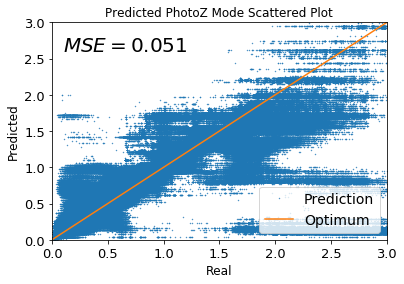

In [18]:
plot_MSE(mode_table)
plt.title('Predicted PhotoZ Mode Scattered Plot')

In [14]:
# Plot the probability density of mean redshift for individual objects

def plot_MSE_pdf(mode_table):
    plt.hexbin(test[:, rz_ind],mode_table,bins = 'log', cmap = 'Blues')
    cb = plt.colorbar()
    xticks(np.arange(0, 3.1, step=0.5))
    yticks(np.arange(0, 3.1, step=0.5))
    plt.tick_params(axis='both', which='major', length = 8, width = 2,labelsize=tick_fontsize)
    plt.xlabel('True Redshift', fontsize=label_fontsize)
    plt.ylabel('Estimated Redshift', fontsize=label_fontsize)
    plt.xlim([0.0, z_max])
    plt.ylim([0.0, z_max])
    plt.axes().set_aspect('equal')
    return None 

/global/common/software/lsst/common/miniconda/py3.7-4.7.12.1-v1/envs/desc/lib/python3.7/site-packages/ipykernel/__main__.py:13: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.


Text(0.5, 1.0, 'Average')

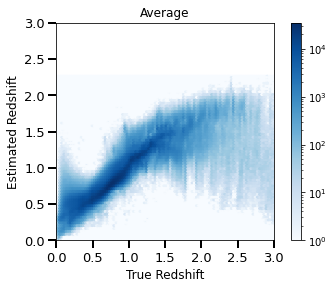

In [15]:
plot_MSE_pdf(ave_table)
plt.title('Average',fontsize=label_fontsize)
#Estimated Redshifts of Individual Galaxies

/global/common/software/lsst/common/miniconda/py3.7-4.7.12.1-v1/envs/desc/lib/python3.7/site-packages/ipykernel/__main__.py:13: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.


Text(0.5, 1.0, 'Mode')

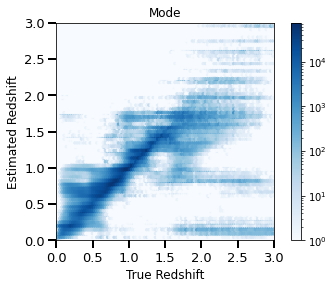

In [16]:
plot_MSE_pdf(mode_table)
plt.title('Mode')

Text(0, 0.5, 'Number of galaxies')

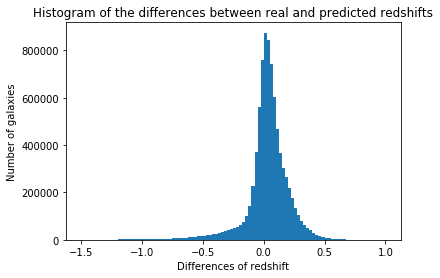

In [22]:
# Plot the histogram of discrepencies between predicted redshift and actual redshift

hist(ave_table-result_data_table['rz_real'],100,(-1.5,1))
title('Histogram of the differences between real and predicted redshifts')
xlabel('Differences of redshift')
ylabel('Number of galaxies')

Text(0.5, 1.0, 'real redshift vs predicted differnces')

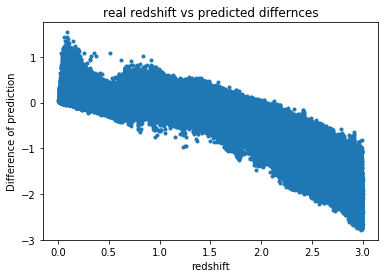

In [23]:
# Plot differences of prediction to true vs. true

plt.plot(result_data_table['rz_real'],ave_table-result_data_table['rz_real'],'.')
plt.xlabel('redshift')
plt.ylabel('Difference of prediction')
plt.title('real redshift vs predicted differnces')

Text(0.5, 1.0, 'Predicted Redshift vs g-r value')

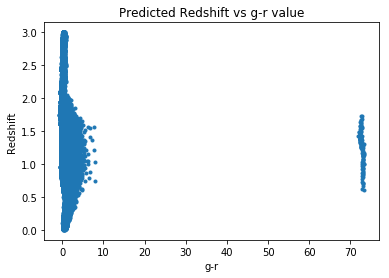

In [24]:
# Plot redshift vs. g-r

plt.plot(test[:,6]-test[:,8],result_data_table['rz_real'],'.'
plt.xlabel('g-r')
plt.ylabel('Redshift')
plt.title('Predicted Redshift vs g-r value')

In [25]:
len(test)

8322249

In [26]:
from matplotlib.colors import Normalize

def plot_color_rz_tot(color1, color2, color_name_1, color_name_2):  
    mask = ((test[:,color1]-test[:,color2])>-1) & ((test[:,color1]-test[:,color2])<2.5)
    mask_t = ((train[:,color1]-train[:,color2])>-1) & ((train[:,color1]-train[:,color2])<2.5)
    
    fig = plt.figure(figsize = (14,15))

    
    ax1 = fig.add_subplot(3,2,1)
    
    im1 = ax1.hexbin(test[mask,color1]-test[mask,color2],np.array(ave_table)[mask], gridsize = (100,100), bins = 10000, cmap = 'Blues') 
    #ax1.set_xlabel(color_name_1 + '-' + color_name_2)
    ax1.set_ylabel('Redshift')
    plt.ylim([0.0, z_max])
    ax1.set_title('Testing Estimated Redshift Average vs ' + color_name_1 + '-' + color_name_2)
    #plt.colorbar(im1,ax=ax1).set_ticks(np.array([10**0,10**1,10**2, 10**3, 10**4, 10**5]), update_ticks = True).update_ticks()
    plt.colorbar(im1,ax=ax1, norm = Normalize(vmin = 0, vmax = 10**3))
    
    '''ax2 = fig.add_subplot(3,2,2)
    im2 = ax2.hexbin(test[mask,color1]-test[mask,color2],np.array(mode_table)[mask], bins = 'log', cmap = 'Blues') 
    #ax2.set_xlabel(color_name_1 + '-' + color_name_2)
    #ax2.set_ylabel('Redshift')
    plt.ylim([0.0, z_max])
    ax2.set_title('Testing Set Estimated Redshift Mode vs ' + color_name_1 + '-' + color_name_2)
    plt.colorbar(im2, ticks = np.array([10**0,10**1,10**2, 10**3, 10**4, 10**5]))
    
    ax3 = fig.add_subplot(3,2,3)
    im3 = ax3.hexbin(test[mask,color1]-test[mask,color2],test[mask, rz_ind], bins = 'log', cmap = 'Blues') 
    #ax3.set_xlabel(color_name_1 + '-' + color_name_2)
    ax3.set_ylabel('Redshift')
    plt.ylim([0.0, z_max])
    ax3.set_title('Testing True Redshift vs ' + color_name_1 + '-' + color_name_2)
    plt.colorbar(im3,ax=ax3, ticks = [10**0,10**1,10**2, 10**3, 10**4, 10**5])'''
    
    
    A0 = np.array([len(test)/len(train)])
    A1 = np.tile(A0,len(train))
    
    ax4 = fig.add_subplot(3,2,4)
    im4 = ax4.hexbin(train[mask_t,color1]-train[mask_t,color2],train[mask_t, rz_ind], C = A1, gridsize = 10000, bins = 10000, cmap = 'Blues', reduce_C_function=np.sum) 
    #ax4.set_xlabel(color_name_1 + '-' + color_name_2)
    #ax4.set_ylabel('Redshift')
    plt.ylim([0.0, z_max])
    ax4.set_title('Weighted training set Redshift vs ' + color_name_1 + '-' + color_name_2)
    #is this name good
    plt.colorbar(im4,ax=ax4, ticks = [10**0,10**1,10**2, 10**3, 10**4, 10**5])
    
    ax5 = fig.add_subplot(3,2,5)
    im5 = ax5.hexbin(train[mask_t,color1]-train[mask_t,color2],train[mask_t, rz_ind], gridsize = (100,100),C = A1, bins = 10000, cmap = 'Blues', reduce_C_function=np.sum) 
    mmmm= im4.get_array()-im1.get_array()
    im5.set_array(mmmm)
    #ax4.set_xlabel(color_name_1 + '-' + color_name_2)
    #ax4.set_ylabel('Redshift')
    plt.ylim([0.0, z_max])
    ax4.set_title('Weighted training set Redshift vs ' + color_name_1 + '-' + color_name_2)
    #is this name good
    plt.colorbar(im5,ax=ax5, ticks = [10**0,10**1,10**2, 10**3, 10**4, 10**5])
    
    '''ax5 = fig.add_subplot(3,2,5)
    im5 = ax5.hexbin(test[mask,color1]-test[mask,color2],test[mask, rz_ind]-np.array(ave_table)[mask], bins = 'log', cmap = 'Blues') 
    ax5.set_xlabel(color_name_1 + '-' + color_name_2)
    ax5.set_ylabel('Redshift Deviations')
    ax5.set_title('Testing Average Redshift Deviation vs ' + color_name_1 + '-' + color_name_2)
    plt.colorbar(im5,ax=ax5, ticks = [10**0,10**1,10**2, 10**3, 10**4, 10**5])
    
    ax6 = fig.add_subplot(3,2,6)
    im6 = ax6.hexbin(test[mask,color1]-test[mask,color2],test[mask, rz_ind]-np.array(mode_table)[mask], bins = 'log', cmap = 'Blues') 
    ax6.set_xlabel(color_name_1 + '-' + color_name_2)
    #ax6.set_ylabel('Redshift')
    ax6.set_title('Testing Redshift Mode Deviation vs ' + color_name_1 + '-' + color_name_2)
    plt.colorbar(im6,ax=ax6, ticks = [10**0,10**1,10**2, 10**3, 10**4, 10**5])'''
    
    plt.show()

ValueError: operands could not be broadcast together with shapes (7717,) (20201,) 

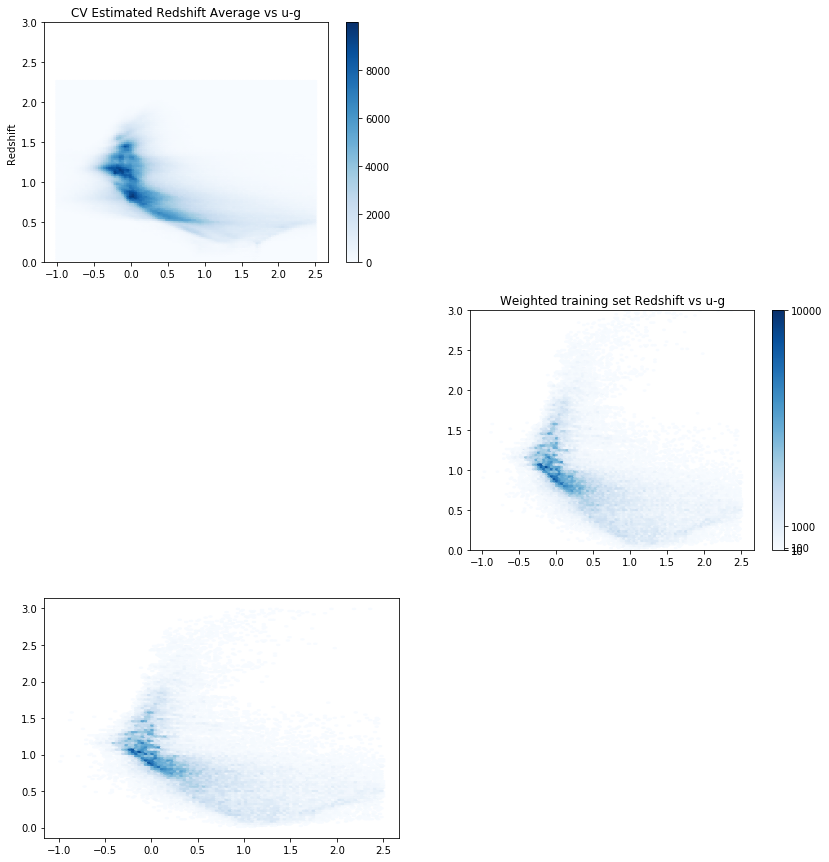

In [103]:
plot_color_rz_tot(4,6,'u','g')

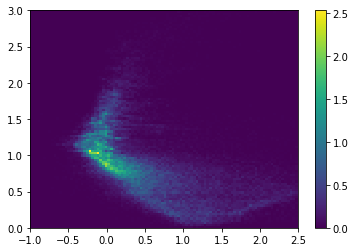

In [6]:
color1 = 4
color2 = 6
mask = ((test[:,color1]-test[:,color2])>-1) & ((test[:,color1]-test[:,color2])<2.5)
mask_t = ((train[:,color1]-train[:,color2])>-1) & ((train[:,color1]-train[:,color2])<2.5)
trainhist = matplotlib.pyplot.hist2d(train[mask_t,color1]-train[mask_t,color2], train[mask_t, rz_ind], bins=100, 
                                     range = [[-1,2.5], [0, 3.0]],normed = True)
plt.colorbar()

In [7]:
distributionT,xedgesT,yedgesT,imageT = trainhist

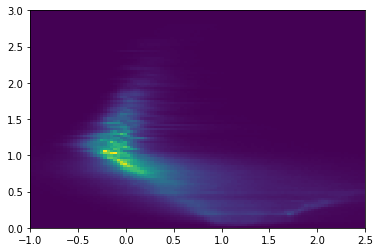

In [8]:
test_true_hist = matplotlib.pyplot.hist2d(test[mask,color1]-test[mask,color2],test[:,1][mask],  bins=100, 
                                        range = [[-1,2.5], [0, 3.0]],normed = True)
#compare with Test true

In [9]:
distributionC,xedgesC,yedgesC,imageC = test_true_hist

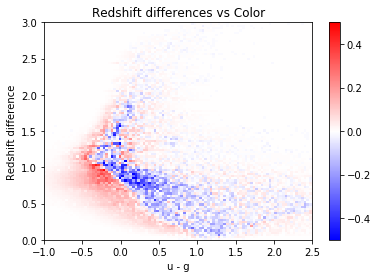

In [91]:
plt.pcolor(xedgesT, yedgesT, (distributionC-distributionT).transpose(), cmap = 'bwr',vmin = -0.5, vmax = 0.5)
plt.title("Redshift differences vs Color")
plt.xlabel("u - g")
plt.ylabel("Redshift difference")
plt.colorbar()

In [67]:
def plot_rz_compa_u(color1,color2,lo,hi):
    mask = ((test[:,color1]-test[:,color2])>lo) & ((test[:,color1]-test[:,color2])<hi)
    mask_t = ((train[:,color1]-train[:,color2])>lo) & ((train[:,color1]-train[:,color2])<=hi)
    fig, m = plt.subplots(1)
    train_hist = np.histogram(train[mask_t, rz_ind],100)
    test_hist = np.histogram(test[mask, rz_ind],100)
    m.plot(train_hist[1][:-1],train_hist[0]/sum(train_hist[0]), '--', label = 'Train', color = 'red')
    m.plot(test_hist[1][:-1],test_hist[0]/sum(test_hist[0]), label = "Testing", color = 'blue')
    m.set_title("Redshift Comparison of u-g in ("+str(lo)+","+str(hi)+"]")
    m.set_xlabel("Redshift")
    m.set_ylabel("Normalized Probability")
    m.legend()

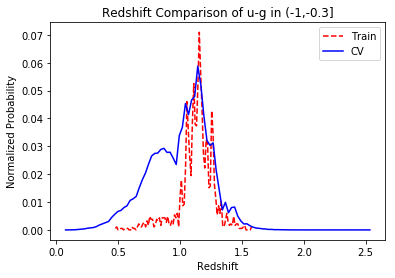

In [68]:
plot_rz_compa_u(4,6,-1,-0.3)

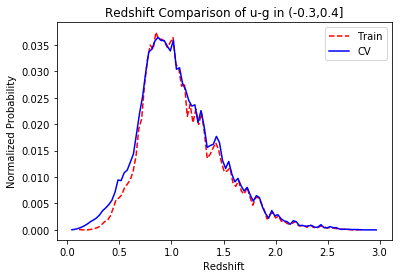

In [62]:
plot_rz_compa_u(4,6,-0.3,0.4)

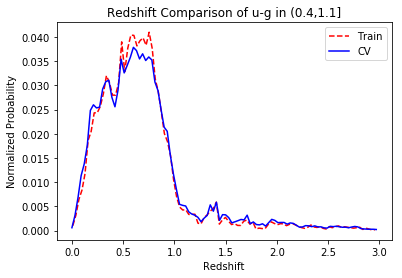

In [63]:
plot_rz_compa_u(4,6,0.4,1.1)

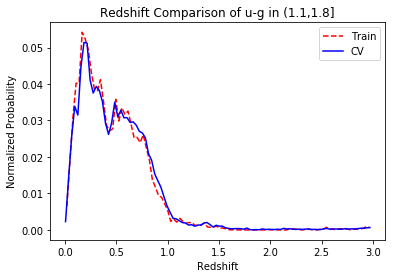

In [64]:
plot_rz_compa_u(4,6,1.1,1.8)

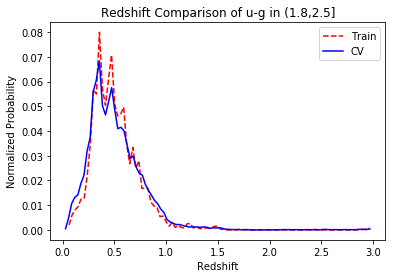

In [65]:
plot_rz_compa_u(4,6,1.8,2.5)

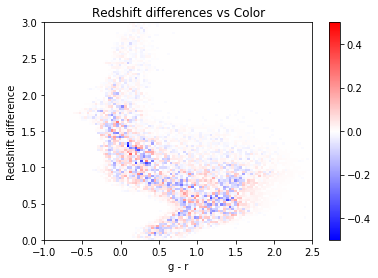

In [69]:
color1 = 6
color2 = 8
mask = ((test[:,color1]-test[:,color2])>-1) & ((test[:,color1]-test[:,color2])<2.5)
mask_t = ((train[:,color1]-train[:,color2])>-1) & ((train[:,color1]-train[:,color2])<2.5)
trainhist = matplotlib.pyplot.hist2d(train[mask_t,color1]-train[mask_t,color2], train[mask_t, rz_ind], bins=100, 
                                     range = [[-1,2.5], [0, 3.0]],normed = True)
distributionT,xedgesT,yedgesT,imageT = trainhist
test_true_hist = matplotlib.pyplot.hist2d(test[mask,color1]-test[mask,color2],test[:,1][mask],  bins=100, 
                                        range = [[-1,2.5], [0, 3.0]],normed = True)
distributionC,xedgesC,yedgesC,imageC = test_true_hist
plt.pcolor(xedgesT, yedgesT, (distributionC-distributionT).transpose(), cmap = 'bwr',vmin = -0.5, vmax = 0.5)
plt.title("Redshift differences vs Color")
plt.xlabel("g - r")
plt.ylabel("Redshift difference")
plt.colorbar()

In [70]:
def plot_rz_compa_g(color1,color2,lo,hi):
    mask = ((test[:,color1]-test[:,color2])>lo) & ((test[:,color1]-test[:,color2])<hi)
    mask_t = ((train[:,color1]-train[:,color2])>lo) & ((train[:,color1]-train[:,color2])<=hi)
    fig, m = plt.subplots(1)
    train_hist = np.histogram(train[mask_t, rz_ind],100)
    test_hist = np.histogram(test[mask, rz_ind],100)
    m.plot(train_hist[1][:-1],train_hist[0]/sum(train_hist[0]), '--', label = 'Train', color = 'red')
    m.plot(test_hist[1][:-1],test_hist[0]/sum(test_hist[0]), label = "Test", color = 'blue')
    m.set_title("Redshift Comparison of g-r in ("+str(lo)+","+str(hi)+"]")
    m.set_xlabel("Redshift")
    m.set_ylabel("Normalized Probability")
    m.legend()

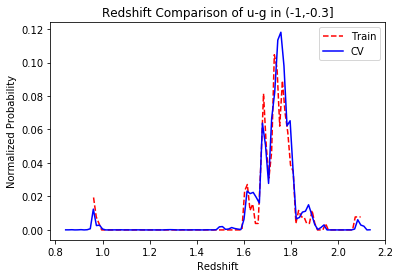

In [71]:
plot_rz_compa_u(6,8,-1,-0.3)

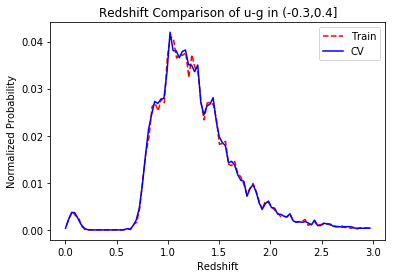

In [72]:
plot_rz_compa_u(6,8,-0.3,0.4)

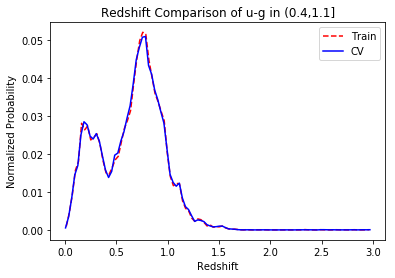

In [73]:
plot_rz_compa_u(6,8,0.4,1.1)

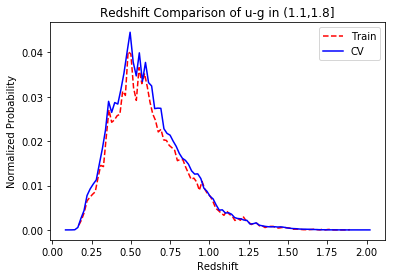

In [74]:
plot_rz_compa_u(6,8,1.1,1.8)

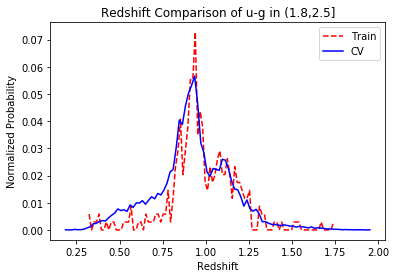

In [75]:
plot_rz_compa_u(6,8,1.8,2.5)

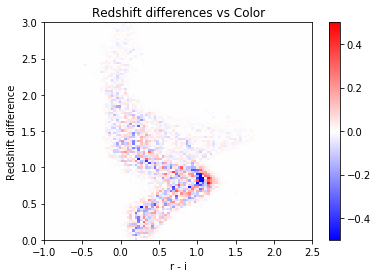

In [93]:
color1 = 8
color2 = 10
mask = ((test[:,color1]-test[:,color2])>-1) & ((test[:,color1]-test[:,color2])<2.5)
mask_t = ((train[:,color1]-train[:,color2])>-1) & ((train[:,color1]-train[:,color2])<2.5)
trainhist = matplotlib.pyplot.hist2d(train[mask_t,color1]-train[mask_t,color2], train[mask_t, rz_ind], bins=100, 
                                     range = [[-1,2.5], [0, 3.0]],normed = True)
distributionT,xedgesT,yedgesT,imageT = trainhist
test_true_hist = matplotlib.pyplot.hist2d(test[mask,color1]-test[mask,color2],test[:,1][mask],  bins=100, 
                                        range = [[-1,2.5], [0, 3.0]],normed = True)
distributionC,xedgesC,yedgesC,imageC = test_true_hist
plt.pcolor(xedgesT, yedgesT, (distributionC-distributionT).transpose(), cmap = 'bwr',vmin = -0.5, vmax = 0.5)
plt.title("Redshift differences vs Color")
plt.xlabel("r - i")
plt.ylabel("Redshift difference")
plt.colorbar()

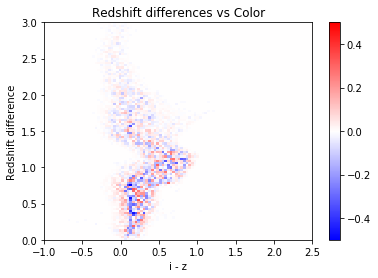

In [94]:
color1 = 10
color2 = 12
mask = ((test[:,color1]-test[:,color2])>-1) & ((test[:,color1]-test[:,color2])<2.5)
mask_t = ((train[:,color1]-train[:,color2])>-1) & ((train[:,color1]-train[:,color2])<2.5)
trainhist = matplotlib.pyplot.hist2d(train[mask_t,color1]-train[mask_t,color2], train[mask_t, rz_ind], bins=100, 
                                     range = [[-1,2.5], [0, 3.0]],normed = True)
distributionT,xedgesT,yedgesT,imageT = trainhist
test_true_hist = matplotlib.pyplot.hist2d(test[mask,color1]-test[mask,color2],test[:,1][mask],  bins=100, 
                                        range = [[-1,2.5], [0, 3.0]],normed = True)
distributionC,xedgesC,yedgesC,imageC = test_true_hist
plt.pcolor(xedgesT, yedgesT, (distributionC-distributionT).transpose(), cmap = 'bwr',vmin = -0.5, vmax = 0.5)
plt.title("Redshift differences vs Color")
plt.xlabel("i - z")
plt.ylabel("Redshift difference")
plt.colorbar()

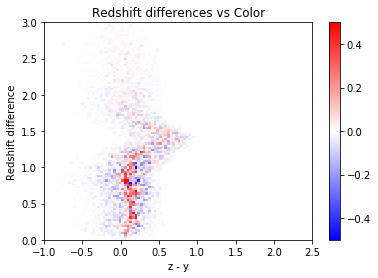

In [95]:
color1 = 12
color2 = 14
mask = ((test[:,color1]-test[:,color2])>-1) & ((test[:,color1]-test[:,color2])<2.5)
mask_t = ((train[:,color1]-train[:,color2])>-1) & ((train[:,color1]-train[:,color2])<2.5)
trainhist = matplotlib.pyplot.hist2d(train[mask_t,color1]-train[mask_t,color2], train[mask_t, rz_ind], bins=100, 
                                     range = [[-1,2.5], [0, 3.0]],normed = True)
distributionT,xedgesT,yedgesT,imageT = trainhist
test_true_hist = matplotlib.pyplot.hist2d(test[mask,color1]-test[mask,color2],test[:,1][mask],  bins=100, 
                                        range = [[-1,2.5], [0, 3.0]],normed = True)
distributionC,xedgesC,yedgesC,imageC = test_true_hist
plt.pcolor(xedgesT, yedgesT, (distributionC-distributionT).transpose(), cmap = 'bwr',vmin = -0.5, vmax = 0.5)
plt.title("Redshift differences vs Color")
plt.xlabel("z - y")
plt.ylabel("Redshift difference")
plt.colorbar()

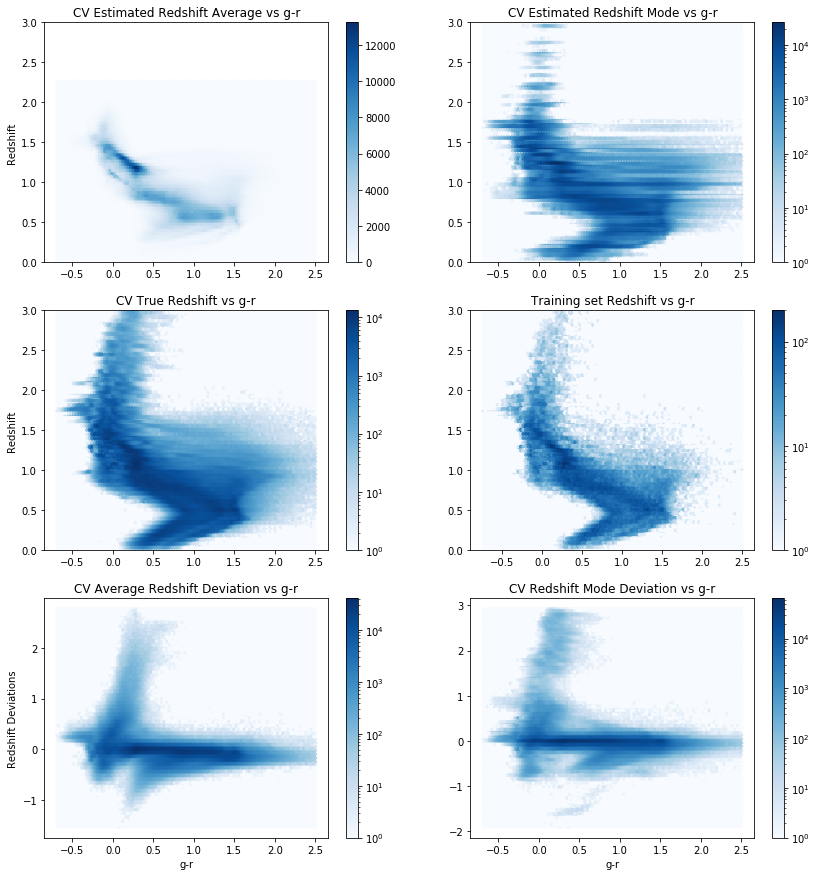

In [27]:
plot_color_rz_tot(6,8,'g','r')

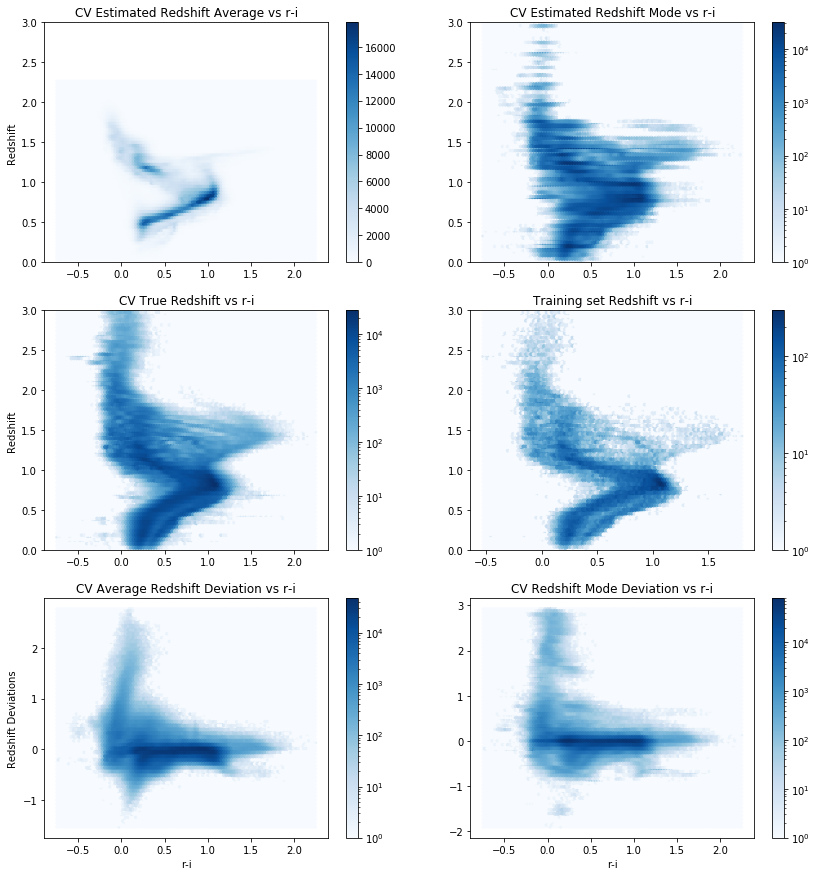

In [28]:
plot_color_rz_tot(8,10,'r','i')

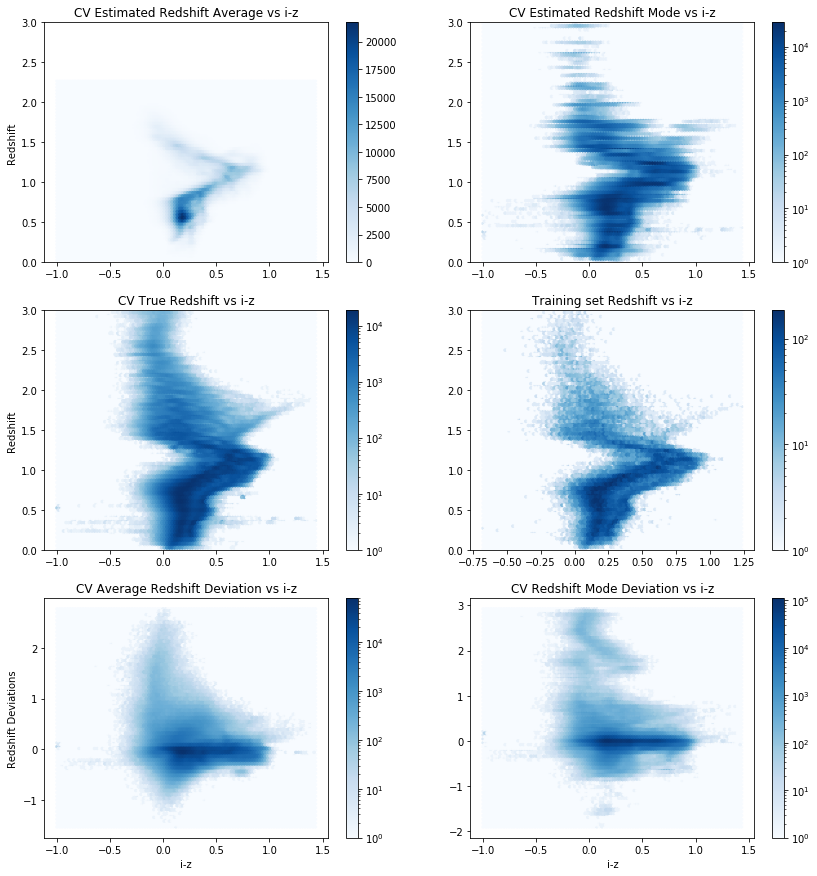

In [29]:
plot_color_rz_tot(10,12,'i','z')

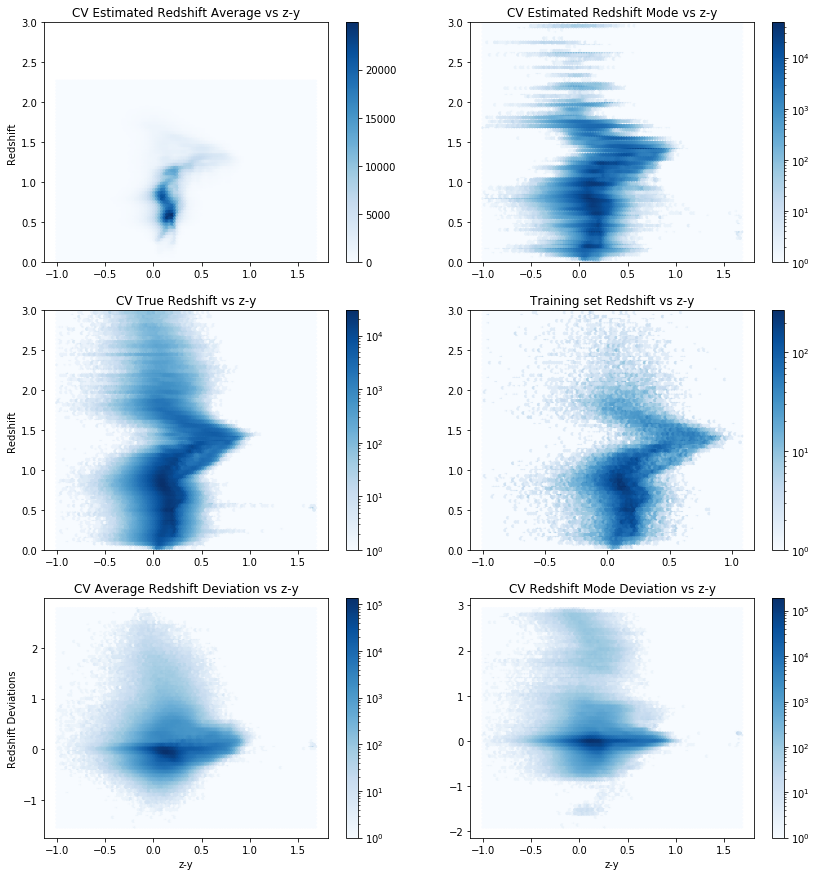

In [30]:
plot_color_rz_tot(12,14,'z','y')

In [ ]:
#plot correlation matrix for a individual galaxy

def plot_gal_cor(data_table,gal_num):
    gal_table = []
    for i in range(len(data_table)):
        gal_table += [data_table[i][gal_num]]
    cov = np.cov(gal_table, rowvar = False)
    diag = cov.diagonal()
    print(diag)
    for j in range (len(cov)):
        for k in range(len(cov[0])):
            cov[j,k] /= math.sqrt(diag[j]*diag[k])
    plt.matshow(cov,cmap = 'bwr')
    cb = plt.colorbar()
    cb.set_label('Value')
    return None

def get_mean_table(data_table):
    mean_table = []
    for i in range(len(data_table)):
        mean_table += [np.mean(data_table[i],axis = 0)]
    return mean_table
    
def get_mean_std(data_table):
    mean_table = get_mean_table(data_table)
    mean = np.mean(mean_table, axis = 0)
    std = np.std(mean_table, axis = 0)
    return (mean, std)

In [ ]:
#plot correlation matrix

mean_table = get_mean_table(result)

cov = np.cov(mean_table, rowvar = False)
diag = cov.diagonal()
edit = copy.deepcopy(cov)
j=0
k=0
for j in range (len(edit)):
    for k in range(len(edit[0])):
        const = diag[j]*diag[k]
        edit[j,k] /= math.sqrt(const)
plt.matshow(edit,cmap = 'bwr')
cb = plt.colorbar()
cb.set_label('Value')

In [ ]:
#plot correlation matrix for one galaxy
plot_gal_cor(result,0)

In [ ]:
#result0-18-0-3
#redshif range 0 to 3, 17 bins
#using cosmoDC2_v1.1.4_small_photoz_magerr_10y with a cut at mag_i < 25.5 as training and testing"
#only has photoz_pdf

#result1-18-0-3
#redshif range 0 to 3, 17 bins
#using /global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/TESTRUN/sample_cosmodc2_w10year_errors.dat as training set
#cosmoDC2_v1.1.4_small_photoz_magerr_10y with a cut at mag_i_obs < 25.0 as cv"
#only has photoz_pdf

#result2-18-0-3
#redshif range 0 to 3, 17 bins
#50 repeats
#using /global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/TESTRUN/sample_cosmodc2_w10year_errors.dat as training set
#shuffled training set 
#cosmoDC2_v1.1.4_small_photoz_magerr_10y with a cut at mag_i_obs < 25.0 as cv

#result3-101-0-3.fits
#redshif range 0 to 3, 100 bins
#10 repeats
#using /global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/TESTRUN/sample_cosmodc2_w10year_errors.dat as training set
#shuffled training set 
#cosmoDC2_v1.1.4_small_photoz_magerr_10y with a cut at mag_i_obs < 25.0 as cv

#result3-101-0-3.parquet
#redshif range 0 to 3, 100 bins
#10 repeats
#using /global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/TESTRUN/sample_cosmodc2_w10year_errors.dat as training set
#shuffled training set 
#cosmoDC2_v1.1.4_small_photoz_magerr_10y with a cut at mag_i_obs < 25.0 as cv

#result4-101-0-3.parquet
#redshif range 0 to 3, 100 bins
#50 repeats
#using /global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/TESTRUN/sample_cosmodc2_w10year_errors.dat as training set
#shuffled training set 
#cosmoDC2_v1.1.4_small_photoz_magerr_10y with a cut at mag_i_obs < 25.0 as cv

#result5-101-0-3.parquet
#redshif range 0 to 3, 100 bins
#10 repeats
#using /global/projecta/projectdirs/lsst/groups/PZ/PhotoZDC2/COSMODC2v1.1.4/10_year_error_estimates/TESTRUN/sample_cosmodc2_w10year_errors.dat as training set
#shuffled training set 
#cosmoDC2_v1.1.4_small_photoz_magerr_10y with a cut at mag_i_obs < 25.0 as cv

#result0.parquet
#redshif range 0 to 3, 100 bins
#50 repeats
#constructed prob_ave while training to solve memory issues

#result1.parquet
#redshif range 0 to 3, 100 bins
#50 repeats
#add a copy of every galaxy with rz >= 2

#result2.parquet
#redshif range 0 to 3, 100 bins
#50 repeats
#add a copy of every galaxy with 
#(train,train[train[:,rz_ind]>= 2],train[train[:,rz_ind]>= 1.6],train[train[:,rz_ind]>= 2.2])